In [2]:
#pandas ke library import ke ha 
import pandas as pd
#numpy ke libarraru use ke ha take datset ke numbers aa sake
import numpy as np
#matplotib dala ha take graphs wagera plot kara sake 
import matplotlib.pyplot as plt
#seaborn library import ha regression or classification ke models use kr sake
import seaborn as sns
#ab isme se hum model select karte ha jisse train testing ho sake
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

#dataset lod kiya ha idhar
df = pd.read_csv('Pima indians diabetes.csv')

#chek kiya ha ke data set load huwa ha ya nhi
print("Shape:", df.shape)
df.head()

Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


In [4]:
#chk karne ke liye kitnemissing valus ha
print("Missing values count:\n", df.isnull().sum())
# ye wo columns  ha jahan data missing ha 
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
#jhaan pr missing value ha mtlb 0 ha tu waha pa median sa vlaeu dale ga
for col in zero_cols:
    zero_count = (df[col] == 0).sum()
    if zero_count > 0:
        print(f"Replacing {zero_count} zeros in {col} with median")
        median_val = df[df[col] != 0][col].median()
        df[col] = df[col].replace(0, median_val)
#duplicates chk krega
print("Dupliactes count:", df.duplicated().sum())
#target distribution
print("\nTarget counts (0: Non-Diabetic, 1: Diabetic):")
print(df['Outcome'].value_counts())

Missing values count:
 Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64
Dupliactes count: 0

Target counts (0: Non-Diabetic, 1: Diabetic):
Outcome
0    500
1    268
Name: count, dtype: int64


In [13]:
# features or target ko alag karta ha or jo outcomes ha uske column ko khatm kr dega
X = df.drop(columns=['Outcome'])
y = df['Outcome']
#train test split ha phele 80 dta train karga or phir 20 test karega
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=100, stratify=y )
#feature scaling ma SVM ke liye zaroori haike decision tree bina scale ke bhi chalta rahe
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Training of data :", X_train.shape)
print("Testing of other data:", X_test.shape)

Training of data : (614, 8)
Testing of other data: (154, 8)


In [19]:
#Decision Tree Classifier (default parameters - unpruned)
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
#Decision tree predictions
dt_train_preds = dt_model.predict(X_train)
dt_test_preds = dt_model.predict(X_test)
#Support Vector Machine (RBF kernel with standard parameters)
svm_model = SVC(kernel='rbf', C=1.0, random_state=42)
svm_model.fit(X_train_scaled, y_train)
#SVM predictions
svm_train_preds = svm_model.predict(X_train_scaled)
svm_test_preds = svm_model.predict(X_test_scaled)

Accurcy comparsion b/w models
           Model  Train Accuracy  Test Accuracy  Accuracy Gap  Train Acccuracy
   Decision Tree             1.0         0.8636        0.1364              NaN
SVM (RBF Kernel)             NaN         0.8571        0.0370           0.8941

 Decision Tree ke Classification Report
              precision    recall  f1-score   support

           0       0.89      0.90      0.90       100
           1       0.81      0.80      0.80        54

    accuracy                           0.86       154
   macro avg       0.85      0.85      0.85       154
weighted avg       0.86      0.86      0.86       154


 SVM Classification  detail
              precision    recall  f1-score   support

           0       0.87      0.92      0.89       100
           1       0.83      0.74      0.78        54

    accuracy                           0.86       154
   macro avg       0.85      0.83      0.84       154
weighted avg       0.86      0.86      0.86       154



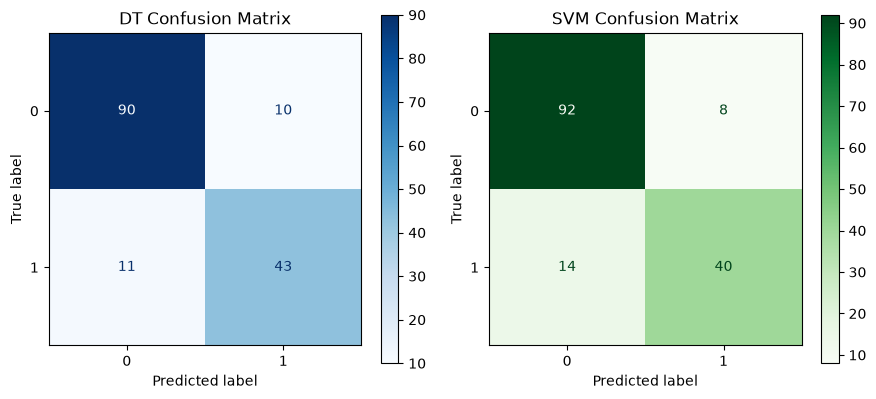

In [20]:
#train test jis model ko kiya ha usme chk krte ha overfitting ko
results = [{   "Model": "Decision Tree",
        "Train Accuracy": round(accuracy_score(y_train, dt_train_preds), 4),
        "Test Accuracy": round(accuracy_score(y_test, dt_test_preds), 4),
        "Accuracy Gap": round(accuracy_score(y_train, dt_train_preds) - accuracy_score(y_test, dt_test_preds), 4) },
    {"Model": "SVM (RBF Kernel)",
        "Train Acccuracy": round(accuracy_score(y_train, svm_train_preds), 4),
        "Test Accuracy": round(accuracy_score(y_test, svm_test_preds), 4),
        "Accuracy Gap": round(accuracy_score(y_train, svm_train_preds) - accuracy_score(y_test, svm_test_preds), 4) }
]
#accuracy cmpare kr rahe ha models
comparison_df = pd.DataFrame(results)
print("Accurcy comparsion b/w models")
print(comparison_df.to_string(index=False))
#decision tree ko classify kar rahe ha detail ma
print("\n Decision Tree ke Classification Report")
print(classification_report(y_test, dt_test_preds))
print("\n SVM Classification  detail")
print(classification_report(y_test, svm_test_preds))
#confusion matrices plot kare ga
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
ConfusionMatrixDisplay.from_predictions(y_test, dt_test_preds, ax=axes[0], cmap='Blues')
axes[0].set_title("DT Confusion Matrix")
ConfusionMatrixDisplay.from_predictions(y_test, svm_test_preds, ax=axes[1], cmap='Greens')
axes[1].set_title("SVM Confusion Matrix")
plt.tight_layout()
plt.show()